# Data Preparation, initial Analysis and Cleaning
Author: Vasileios Tsoumpris

In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
from pathlib import Path

from matplotlib.pyplot import title

## Reading file/s

In [2]:
root = Path.cwd().parent
dataset_path = \
    root / 'data' / 'interim' / 'splitted' / 'X_train_mini.csv'

df = pd.read_csv(dataset_path)

# rows and columns
print("The dataset contains ", df.shape[0], " rows and ", df.shape[1], " features.")
df.head()

The dataset contains  65129  rows and  49  features.


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,146463126,23312916,AfricanAmerican,Female,[40-50),?,1,3,5,8,...,No,No,Steady,No,No,No,No,No,No,Yes
1,42768240,888327,Caucasian,Female,[60-70),?,1,1,7,2,...,No,No,No,No,No,No,No,No,No,No
2,288867768,45861579,Caucasian,Female,[60-70),?,2,1,7,13,...,No,No,Up,No,No,No,No,No,Ch,Yes
3,79126704,383058,AfricanAmerican,Female,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,No,Yes
4,214896840,38385846,Caucasian,Male,[80-90),?,1,3,7,4,...,No,No,Down,No,No,No,No,No,Ch,Yes


## Data Analysis and Initial Cleaning of Data

### 1. Is there any encounter_id that is repeated?

In [3]:
# the question is:
# Any patient who has readmitted multiple times?
df["encounter_id"].duplicated(keep = False).unique()

array([False])

Only one unique value (False) indicating that there are no duplicate encounter_ids.

### 2. Is there any patient who has readmitted multiple times?

In [4]:
print("Distinct number of patients: ",
      df["patient_nbr"].value_counts().shape[0])
df["patient_nbr"].value_counts().head(10)
# or use this (it is the same):
# df[["patient_nbr"]].groupby("patient_nbr").size().sort_values(ascending=False).head(10)

Distinct number of patients:  50322


patient_nbr
88785891     25
1660293      21
43140906     19
92709351     18
84348792     15
88681950     15
23643405     15
106757478    14
88789707     14
41617368     14
Name: count, dtype: int64

There are multiple patients who have been readmitted multiple times.

What should we do with these patients?

### 3. How many unique values in demographic features are there?
(features: gender, race, age)

Function used

In [5]:
def analyse_unique_values(dfr, column_name, plot_bar = True):
    """ Analyse unique values and NAs in a feature."""

    # count the number of unique values in the feature
    analysis_df = dfr[[column_name]].groupby(column_name).size().sort_values(ascending=False)
    # draft a plot of the number of unique values (horizontal bar chart)
    if plot_bar:
        analysis_df.plot(kind = 'barh',
                         title = f'Number of encounters {column_name}'
                         )
    # identify any NA values
    # find any NA values in the feature,
    # and if exist return True, else False
    has_na = dfr[column_name].isna().any()
    # count the number of NA values
    count_na = dfr[column_name].isna().sum()
    # print the results for NA analysis
    print(f'NAs identified in feature:'
          f'{column_name} with a count of {count_na}' if has_na
          else f'No NAs identified in {column_name} (count = {count_na})' ,)

    print(analysis_df)

    return analysis_df

#### Race

No NAs identified in race (count = 0)
race
Caucasian          48773
AfricanAmerican    12244
?                   1426
Hispanic            1315
Other                948
Asian                423
dtype: int64


race
Caucasian          48773
AfricanAmerican    12244
?                   1426
Hispanic            1315
Other                948
Asian                423
dtype: int64

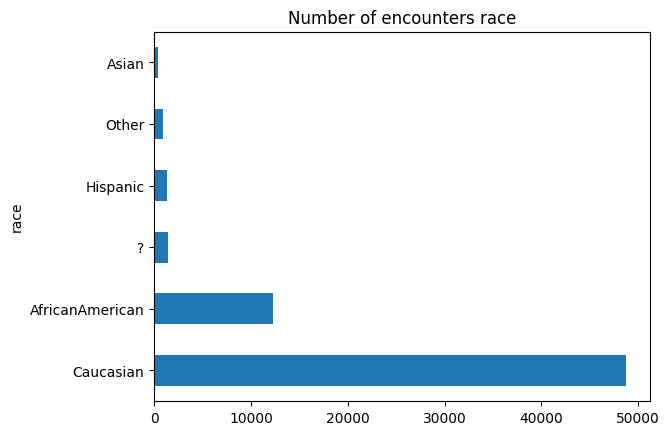

In [6]:
analyse_unique_values(dfr = df, column_name = 'race')

Found the '?' which is likely a placeholder for missing data. How should we handle this?

A possible strategy is to convert to 'Unknown'.

#### Gender

No NAs identified in gender (count = 0)
gender
Female             35098
Male               30028
Unknown/Invalid        3
dtype: int64


gender
Female             35098
Male               30028
Unknown/Invalid        3
dtype: int64

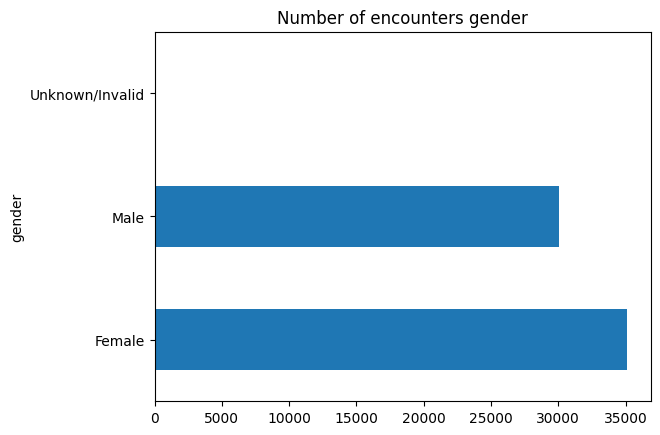

In [7]:
analyse_unique_values(dfr = df, column_name = 'gender')

An imputation strategy is possible for **gender** feature.

#### Age

No NAs identified in age (count = 0)
age
[70-80)     16687
[60-70)     14440
[50-60)     11104
[80-90)     10903
[40-50)      6181
[30-40)      2415
[90-100)     1786
[20-30)      1073
[10-20)       448
[0-10)         92
dtype: int64


age
[70-80)     16687
[60-70)     14440
[50-60)     11104
[80-90)     10903
[40-50)      6181
[30-40)      2415
[90-100)     1786
[20-30)      1073
[10-20)       448
[0-10)         92
dtype: int64

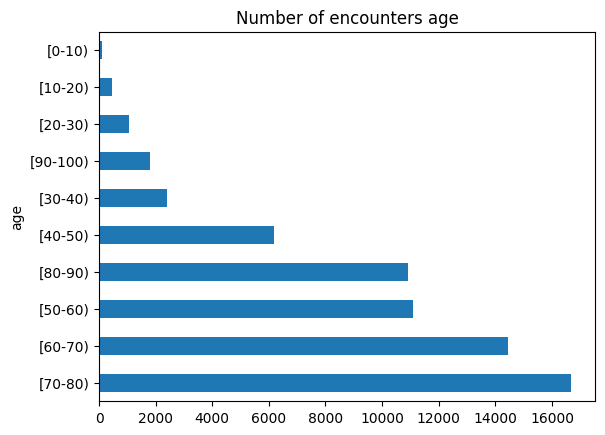

In [8]:
analyse_unique_values(dfr = df, column_name = 'age')

Age feature has no missing values.

### 5. What about the feature of **weight**?

No NAs identified in weight (count = 0)
weight
?            63024
[75-100)       873
[50-75)        606
[100-125)      405
[125-150)      102
[25-50)         58
[0-25)          34
[150-175)       21
[175-200)        4
>200             2
dtype: int64


weight
?            63024
[75-100)       873
[50-75)        606
[100-125)      405
[125-150)      102
[25-50)         58
[0-25)          34
[150-175)       21
[175-200)        4
>200             2
dtype: int64

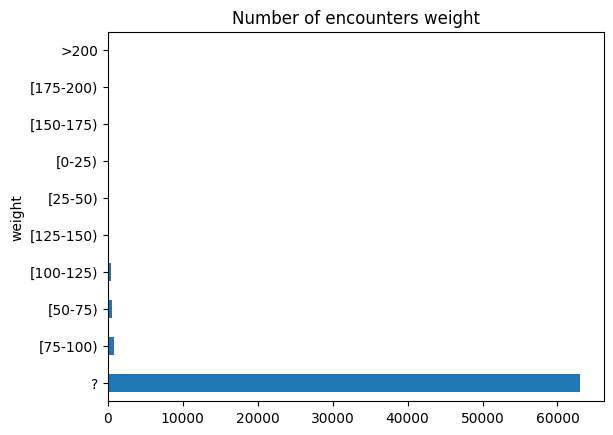

In [9]:
analyse_unique_values(df, 'weight')

This feature has many '?' values. We should consider adding this feature later on our model as it may be important for predicting the outcome. On the other hand the majority of the values are '?'.